# Atividade Perceptron Manual com Dataset do Kaggle

Este notebook implementa um Perceptron **manual**, sem uso de NumPy,
utilizando dados derivados de um dataset baseado na franquia *Resident Evil*.

O objetivo é:

- Criar um dataset com **duas entradas numéricas**.
- Definir um rótulo binário: *hero (0)* e *villain (1)*.
- Implementar o Perceptron manual.
- Treinar o modelo.
- Visualizar gráficos.
- Testar previsões.


#### Visualização em Tabela dos Datasets

In [80]:
# Mostrar dados em tabelas HTML usando IPython.display

from IPython.display import HTML

df_char = pd.read_csv('../data/raw/characters.csv')
df_gameAp = pd.read_csv('../data/raw/gameAppearance.csv')
df_interactions = pd.read_csv('../data/raw/interactions.csv')

html = """
<div style="display:flex; gap:20px;">

    <div>
        <h3>Characters</h3>
        {}
    </div>

    <div>
        <h3>Game Appearance</h3>
        {}
    </div>

    <div>
        <h3>Interactions</h3>
        {}
    </div>

</div>
""".format(
    df_char.head().to_html(),
    df_gameAp.head().to_html(),
    df_interactions.head().to_html()
)

HTML(html)

### Importação dos datasets e criação de dataset final

In [44]:
# Mostrar dados em tabela

import pandas as pd
import matplotlib.pyplot as plt

# Carregar CSVs
characters = pd.read_csv('../data/raw/characters.csv')
interactions = pd.read_csv('../data/raw/interactions.csv')
game_app = pd.read_csv('../data/raw/gameAppearance.csv')

# Renomear para manter nomes consistentes
characters = characters.rename(columns={
    "id": "character_id",
    "name": "character_name"
})

# Consolidar personagens (caso haja duplicados)
characters_clean = characters.groupby("character_id").agg({
    "character_name": "first",
    "role": "first"
}).reset_index()

# Contar cenas por personagem
scenes_count = interactions.groupby("character_id").size().reset_index(name="total_scenes")

# Contar aparições em jogos
games_count = game_app.groupby("character_id").size().reset_index(name="total_games")

# Unir tudo em uma tabela final
final_df = characters_clean.merge(scenes_count, on="character_id", how="left") \
                           .merge(games_count, on="character_id", how="left")

final_df["label"] = final_df["role"].map({"hero": 0, "villain": 1})

# Substituir NaN por 0 (caso algum personagem não apareça em cenas/jogos)
final_df = final_df.fillna(0)

final_df

,character_id,character_name,role,total_scenes,total_games,label
0,1,Leon Scott Kennedy,hero,244.0,4.0,0.0
1,2,Ashley Graham,hero,9.0,1.0,0.0
2,3,Ada Wong,hero,39.0,3.0,0.0
3,4,Ingrid Hunnigan,hero,0.0,2.0,0.0
4,5,Luis Sera,hero,4.0,1.0,0.0
...,...,...,...,...,...,...
78,79,Donna Beneviento,villain,0.0,1.0,1.0
79,80,Grace Ashcroft,hero,267.0,1.0,0.0
80,81,Victor Gideon,villain,36.0,1.0,1.0
81,82,Nathan Dempsey,support,13.0,1.0,0.0


### Gráficos

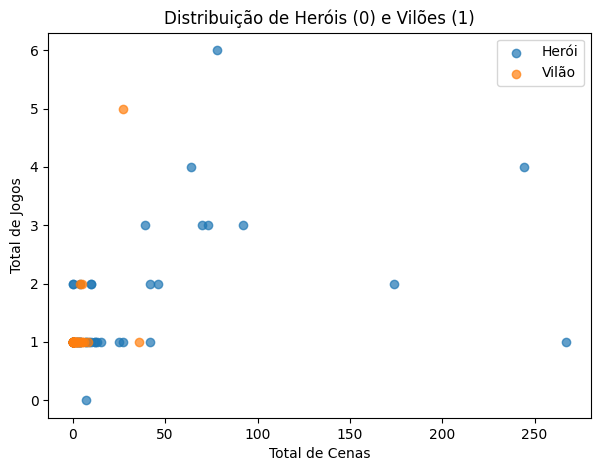

In [52]:
# Visualizar a distribuição de heróis e vilões com base no total de cenas e jogos

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(7,5))

# Heróis (label = 0)
plt.scatter(
    final_df[final_df["label"] == 0]["total_scenes"],
    final_df[final_df["label"] == 0]["total_games"],
    label="Herói",
    alpha=0.7
)

# Vilões (label = 1)
plt.scatter(
    final_df[final_df["label"] == 1]["total_scenes"],
    final_df[final_df["label"] == 1]["total_games"],
    label="Vilão",
    alpha=0.7
)
plt.xlabel("Total de Cenas")
plt.ylabel("Total de Jogos")
plt.title("Distribuição de Heróis (0) e Vilões (1)")
plt.legend()
plt.show()

### Lógica Perceptron

In [73]:
class Perceptron:
    def __init__(self, weights=None, bias=0.1):
        default_weights = {'total_scenes': 0.0, 'total_games': 0.0}  # Para features: total_scenes e total_games
        self.weights = weights if weights is not None else default_weights
        self.bias = bias
    
    def predict(self, scenes, games):
        # calculo
        w_scenes = self.weights.get('total_scenes', 0.0)
        w_games = self.weights.get('total_games', 0.0)
        
        # soma ponderada
        linear_output = (scenes * games) + (games * w_games) + self.bias
        
        # ativacao (degrau)
        prediction = 1 if linear_output >= 0 else 0
        
        return {
            "prediction": prediction,
            "activation": linear_output,
        }
    
    def train(self, X, y, epochs=10, lr=0.1):
        for epoch in range(epochs):
            for (scenes, games), target in zip(X, y):
                result = self.predict(scenes, games)["prediction"]
                error = target - result

                # atualização dos pesos
                self.weights['total_scenes'] += lr * error * scenes
                self.weights['total_games'] += lr * error * games
                self.bias += lr * error

In [74]:
# preparar dados
X = final_df[["total_scenes", "total_games"]].values.tolist()
y = final_df["label"].values.tolist()

# criar e treinar perceptron
p = Perceptron()
print("Pesos iniciais:", p.weights, "Bias inicial:", p.bias)

p.train(X, y, epochs=20, lr=0.01)

print("Pesos finais:", p.weights, "Bias final:", p.bias)

Pesos iniciais: {'total_scenes': 0.0, 'total_games': 0.0} Bias inicial: 0.1
Pesos finais: {'total_scenes': -274.37999999999937, 'total_games': -5.510000000000026} Bias final: -0.6700000000000004


### Gráfico fronteira de decisão

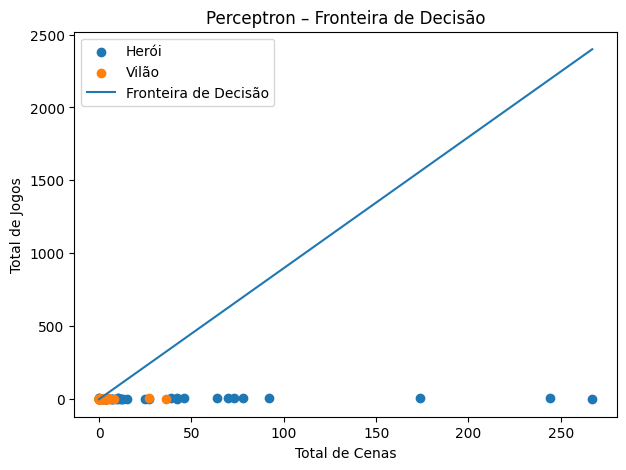

In [79]:
# ----- Gráfico -----
plt.figure(figsize=(7,5))

# Heróis
plt.scatter(
    final_df[final_df["label"] == 0]["total_scenes"],
    final_df[final_df["label"] == 0]["total_games"],
    label="Herói"
)

# Vilões
plt.scatter(
    final_df[final_df["label"] == 1]["total_scenes"],
    final_df[final_df["label"] == 1]["total_games"],
    label="Vilão"
)

# ----- Fronteira de decisão -----
w1 = p.weights['total_scenes']
w2 = p.weights['total_games']
b = p.bias

x_vals = np.linspace(final_df["total_scenes"].min(), final_df["total_scenes"].max(), 100)

if w2 != 0:
    y_vals = -(w1 * x_vals + b) / w2
    plt.plot(x_vals, y_vals, label="Fronteira de Decisão")
else:
    plt.axvline(-b / w1, label="Fronteira de Decisão")

plt.xlabel("Total de Cenas")
plt.ylabel("Total de Jogos")
plt.title("Perceptron – Fronteira de Decisão")
plt.legend()
plt.show()

##### O que o Perceptron aprendeu com o dataset?

Usando os atributos:

- ```total_scenes``` (quantas cenas cada personagem aparece),
- ```total_games``` (quantos jogos o personagem participa),

o Perceptron tenta encontrar uma regra matemática que separe os personagens heróis dos vilões. Durante o treinamento:

- Ele compara sua predição com a classe real (hero/villain),
- Calcula o erro,
- Ajusta os pesos e o bias para reduzir esse erro.

Esse processo é repetido várias vezes (epochs) até encontrar um limite de separação adequado.

##### O que representa o gráfico?

O gráfico mostra Pontos do dataset
- Cada ponto representa um personagem.
- A posição no eixo X indica o total de cenas.
- A posição no eixo Y indica o total de jogos.
- A cor indica a classe real (herói ou vilão).